# Scenario 1: Optimising stop order within one route
This notebook tests a simple routing scenario where the stop order within one selected vehicle route is optimised. The purpose is to show how predicted service times can be combined with operational constraints such as time windows in a route planning problem. The scenario is simplified and uses only a small number of stops to make the optimisation easier to inspect.model.

## Import libraries

Pandas and NumPy are used for data handling, while Matplotlib is used for visualisation. Google OR-Tools is used to solve the routing problem, as it is suitable for vehicle routing problems with operational constraints.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

C:\Users\tuvap\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\tuvap\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Select scenario settings

A delivery date is selected for the scenario. The number of stops is limited to five so the result is easier to analyse and visualise.

In [3]:
chosenDate = "2025-06-16"
maxStops = 5

## Define column names
Important column names are stored in variables to make the notebook easier to read and maintain. The scenario uses customer IDs, route IDs, time windows and predicted service times. time.

In [4]:
customerColumn = "Kundenr"
dateColumn = "Dato"
shiftColumn = "Kjøreskift ID"
startWindow = "Leveringsvindu fra"
endWindow = "Leveringsvindu til"
predColumn = "predikert_leveringstid"
actualColumn = "Leveringstid (min)"

## Load prediction and historical data

predictions.csv is the dataset created earlier - it contains the predicted service times from the TFT model. merged_clean_7years.csv is the cleaned historical dataset - it contains operational data such as routes and delivery windows. Both are needed because the scenario combines model predictions with real planning.

In [5]:
predData = pd.read_csv("predictions.csv")
historyData = pd.read_csv("merged_clean_7years.csv", low_memory=False)

## Prepare dates for merging

The date columns are converted to datetime format, and a separate date field is created in both datasets. This is done so the prediction data and historical data can be matched using the same delivery date.

In [6]:
predData[dateColumn] = pd.to_datetime(predData[dateColumn], errors="coerce")
historyData[dateColumn] = pd.to_datetime(historyData[dateColumn], errors="coerce")

predData["mergeDate"] = predData[dateColumn].dt.date
historyData["mergeDate"] = historyData[dateColumn].dt.date

## Prepare customer IDs for merging

Customer IDs are converted to numeric format in both datasets to get match.

In [7]:
predData[customerColumn] = pd.to_numeric(predData[customerColumn], errors="coerce")
historyData[customerColumn] = pd.to_numeric(historyData[customerColumn], errors="coerce")

## Merge predictions with historical delivery data 

The predicted service times are merged into the historical dataset using customer ID and delivery date. A left join is used so all historical deliveries are kept, even if a prediction is missing. The selected scenario date is then filtered for the analysis.

In [8]:
smallPredData = predData[["mergeDate", customerColumn, predColumn]]
data = historyData.merge(smallPredData, on=["mergeDate", customerColumn], how="left")

chosenDate = pd.to_datetime(chosenDate).date()
dayData = data[data["mergeDate"] == chosenDate].copy()

if dayData.empty:
    raise ValueError("No rows found for chosen date")

## Select one vehicle route for the scenario

For the chosen date, the vehicle route with the highest number of deliveries is selected to ensure enough data. This will give a practical route with enough stops to demonstrate the optimisation in a clear way.

In [9]:
chosenShift = dayData[shiftColumn].value_counts().idxmax()
routeData = dayData[dayData[shiftColumn] == chosenShift].copy()

print("Chosen date:", chosenDate)
print("Chosen shift:", chosenShift)
print("Rows before filter:", len(routeData))

Chosen date: 2025-06-16
Chosen shift: 5679647.0
Rows before filter: 22


## Prepare delivery time windows

Valid delivery time windows are required for the optimisation model. Rows with missing or invalid time intervals are therefore removed.

In [10]:
routeData[startWindow] = pd.to_datetime(routeData[startWindow], errors="coerce")
routeData[endWindow] = pd.to_datetime(routeData[endWindow], errors="coerce")

routeData = routeData.dropna(subset=[startWindow, endWindow]).copy()

print("Rows after window filter:", len(routeData))

Rows after window filter: 22


## Create service time input 

The service time used in the optimisation is based on the predicted service time from the TFT model. If a prediction is missing, the actual historical service time is used instead. Values are rounded to whole minutes because OR-Tools works with integer values.

In [11]:
routeData["serviceTime"] = routeData[predColumn].fillna(routeData[actualColumn])
routeData["serviceTime"] = routeData["serviceTime"].round().astype(int)

## Sort stops by original delivery order

The route is sorted by recorded delivery start time when available. If this is missing, the start of the delivery window is used instead. This creates a baseline route order that can later be compared with the optimised route to compare.

In [12]:
if "Start Levering" in routeData.columns:
    routeData["Start Levering"] = pd.to_datetime(routeData["Start Levering"], errors="coerce")

    if routeData["Start Levering"].notna().sum() > 0:
        routeData = routeData.sort_values("Start Levering")
    else:
        routeData = routeData.sort_values(startWindow)
else:
    routeData = routeData.sort_values(startWindow)

routeData = routeData.reset_index(drop=True)

## Limit the route size

Only the first selected stops are kept so the scenario remains small, easy to inspect, and suitable as a prototype tool before possible expansion. At least two stops are required, since optimisation would not be meaningful with only one stop.

In [13]:
routeData = routeData.head(maxStops).copy()
routeData = routeData.reset_index(drop=True)

routeData["stopNumber"] = range(1, len(routeData) + 1)

if len(routeData) < 2:
    raise ValueError("Too few stops left")

print("Rows used:", len(routeData))

Rows used: 5


## Convert time windows to minutes

Time windows are converted to minutes after midnight, since OR-Tools requires numerical time values.

In [14]:
def toMinutes(timeValue):
    return timeValue.hour * 60 + timeValue.minute

routeData["startMin"] = routeData[startWindow].apply(toMinutes)
routeData["endMin"] = routeData[endWindow].apply(toMinutes)

## Create customer and service time lists

Customer IDs and service times are stored as lists so they can be used directly in the routing model. The depot starts with zero service time.

In [15]:
customerList = routeData[customerColumn].astype(int).tolist()
serviceList = [0] + routeData["serviceTime"].tolist()

## Create simplified travel time matrix

A travel time matrix is created for all stops and the depot. Random travel times are used in this prototype to demonstrate the optimisation logic without requiring any map data or real addresses. A fixed random seed is used so results remain reproducible.

In [16]:
nodeCount = len(customerList) + 1

travelTime = np.zeros((nodeCount, nodeCount), dtype=int)
randomData = np.random.RandomState(42)

for startStop in range(nodeCount):
    for endStop in range(nodeCount):

        if startStop != endStop:
            travelTime[startStop, endStop] = int(
                randomData.uniform(3, 10)
            )

## Combine depot and customer time windows

The depot is given a full-day time window, while customer time windows are taken from the historical data. These are later used as constraints in the optimisation model.

In [17]:
depotWindow = (0, 24 * 60)
customerWindows = list(zip(routeData["startMin"], routeData["endMin"]))
allWindows = [depotWindow] + customerWindows

## Build and solve the OR-Tools routing model

A routing model with one vehicle and one depot is created to represent the simplified scenario. Travel and service times are included so the solver considers realistic stop durations, not only distance. Delivery windows are added as time constraints, which ensures that the suggested route is feasible in practice. A simple heuristic is appropriate because the scenario is small and mainly intended to demonstrate the decision-support logic rather than solve a full-scale routing problem.

In [18]:
manager = pywrapcp.RoutingIndexManager(nodeCount, 1, 0)
routing = pywrapcp.RoutingModel(manager)

def timeCallback(startIndex, endIndex):
    startStop = manager.IndexToNode(startIndex)
    endStop = manager.IndexToNode(endIndex)

    return travelTime[startStop, endStop] + serviceList[startStop]

timeIndex = routing.RegisterTransitCallback(timeCallback)
routing.SetArcCostEvaluatorOfAllVehicles(timeIndex)
routing.AddDimension(timeIndex, 60, 24 * 60, False, "Time")

timeDim = routing.GetDimensionOrDie("Time")

for stopNumber in range(nodeCount):
    startTime, endTime = allWindows[stopNumber]
    stopIndex = manager.NodeToIndex(stopNumber)
    timeDim.CumulVar(stopIndex).SetRange(startTime, endTime)

params = pywrapcp.DefaultRoutingSearchParameters()
params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
params.time_limit.seconds = 10

solution = routing.SolveWithParameters(params)

if solution is None:
    raise ValueError("No solution found. Try another date or fewer stops.")

## Extract optimised route order

After/if a solution is found, the optimised stop sequence is converted back to customer IDs. This makes it possible to compare the suggested route with the original delivery order.

In [19]:
routeStops = []
routeIndex = routing.Start(0)

while not routing.IsEnd(routeIndex):
    routeStops.append(manager.IndexToNode(routeIndex))
    routeIndex = solution.Value(routing.NextVar(routeIndex))

optimalOrder = []

for stopNumber in routeStops:
    if stopNumber != 0:
        customerId = customerList[stopNumber - 1]
        optimalOrder.append(customerId)

print("Original order:")
print(routeData[customerColumn].astype(int).tolist())

print("Optimised order:")
print(optimalOrder)

Original order:
[790907, 1349830, 1040785, 1124001, 1263502]
Optimised order:
[1263502, 1124001, 1040785, 790907, 1349830]


## Calculate arrival times for the baseline route

Arrival times are calculated for the original route order to create a baseline. Waiting time is included if the vehicle arrives before a delivery window opens. This makes the baseline more realistic, because vehicles can not deliver before the allowed time window - that is considered an deviation.

In [20]:
baseTimes = []

currentTime = routeData["startMin"].iloc[0]
for stopNumber in range(len(routeData)):

    if stopNumber == 0:
        currentTime = max(currentTime, routeData["startMin"].iloc[stopNumber])
    else:
        currentTime += travelTime[stopNumber, stopNumber + 1]
        currentTime = max(currentTime, routeData["startMin"].iloc[stopNumber])

    baseTimes.append(currentTime)
    currentTime += routeData["serviceTime"].iloc[stopNumber]

## Calculate arrival times for the optimised route

The same arrival time calculation is repeated for the optimised route. This is important because both routes must be evaluated using the same assumptions to be able to compare fairly. The comparison then shows the effect of changing the stop order only.

In [21]:
customerToRow = {}

for rowNumber in range(len(routeData)):
    customerId = int(routeData.iloc[rowNumber][customerColumn])
    customerToRow[customerId] = rowNumber

optTimes = []

currentTime = routeData["startMin"].min()
previousStop = 0

for customerId in optimalOrder:
    rowNumber = customerToRow[customerId]
    currentStop = rowNumber + 1

    currentTime += travelTime[previousStop, currentStop]
    currentTime = max(currentTime, routeData.iloc[rowNumber]["startMin"])
    optTimes.append(currentTime)
    currentTime += routeData.iloc[rowNumber]["serviceTime"]
    previousStop = currentStop

## Convert minutes back to clock time

The optimisation model uses minutes after midnight, but this is not very easy to read. The values are therefore converted back to HH:MM format so the arrival times can be interpreted more clearly and understandable. 

In [22]:
def toHhmm(minutes):
    hour = minutes // 60
    minute = minutes % 60

    return f"{hour:02d}:{minute:02d}"

## Visualise baseline and optimised arrival times

The plot compares arrival times for the original route and the optimised route. This makes it easier to see whether the new stop order gives earlier arrivals or more slack in the schedule. This is useful because more slack can make the route less sensitive to delays.

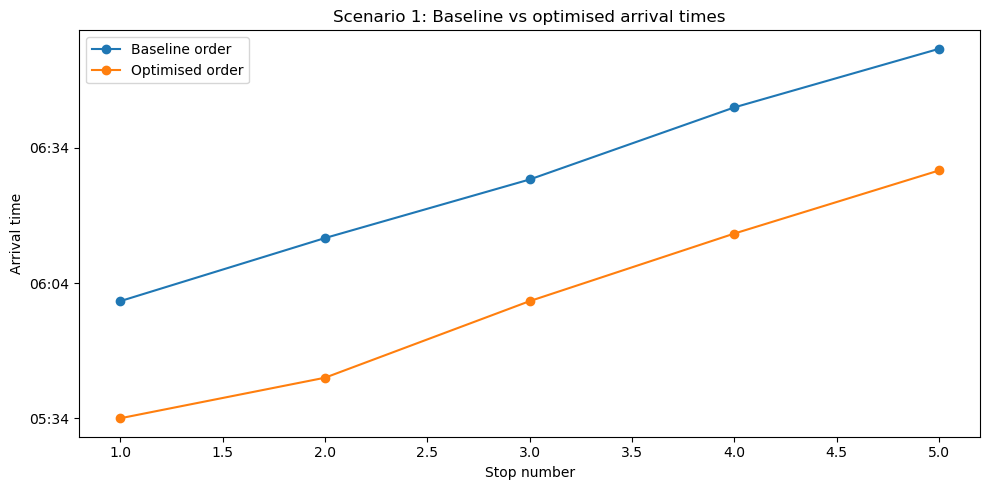

In [23]:
plt.figure(figsize=(10, 5))

baseX = range(1, len(baseTimes) + 1)
optX = range(1, len(optTimes) + 1)

plt.plot(baseX, baseTimes, marker="o", label="Baseline order")
plt.plot(optX, optTimes, marker="o", label="Optimised order")
plt.xlabel("Stop number")
plt.ylabel("Arrival time")
plt.title("Scenario 1: Baseline vs optimised arrival times")
ticks = range(min(baseTimes + optTimes), max(baseTimes + optTimes) + 1, 30)
plt.yticks(ticks, [toHhmm(timeValue) for timeValue in ticks])
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
comparisonTable = pd.DataFrame({
    "Stop number": range(1, len(routeData)+1),
    "Baseline customer": routeData[customerColumn].astype(int).tolist(),
    "Optimised customer": optimalOrder
})

print(comparisonTable.to_string(index=False))

 Stop number  Baseline customer  Optimised customer
           1             790907             1263502
           2            1349830             1124001
           3            1040785             1040785
           4            1124001              790907
           5            1263502             1349830


In [24]:
import json

with open("5 scenario testing 1.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        print("\n" + "="*70)
        print(f"CELL {i}")
        print("="*70)
        print("".join(cell["source"]))



CELL 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

CELL 4
chosenDate = "2025-06-16"
maxStops = 5

CELL 6
customerColumn = "Kundenr"
dateColumn = "Dato"
shiftColumn = "Kjøreskift ID"
startWindow = "Leveringsvindu fra"
endWindow = "Leveringsvindu til"
predColumn = "predikert_leveringstid"
actualColumn = "Leveringstid (min)"

CELL 8
predData = pd.read_csv("predictions.csv")
historyData = pd.read_csv("merged_clean_7years.csv", low_memory=False)

CELL 10
predData[dateColumn] = pd.to_datetime(predData[dateColumn], errors="coerce")
historyData[dateColumn] = pd.to_datetime(historyData[dateColumn], errors="coerce")

predData["mergeDate"] = predData[dateColumn].dt.date
historyData["mergeDate"] = historyData[dateColumn].dt.date

CELL 12
predData[customerColumn] = pd.to_numeric(predData[customerColumn], errors="coerce")
historyData[customerColumn] = pd.to_numeric(historyData[customerColumn], errors="coe